# Continuous Optimization: Nonlinear Programming

In [ ]:
# This code cell installs packages on Colab

import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

# `helper` is the ONE course module: the Colab install above, the house figure
# style, and the extract / archive / save-the-figure plumbing this notebook uses
# further down. It used to take a second `wget` for `pyomo_results.py`; that
# module is now a shim over this one, and one file is one thing that can fail.


In [2]:
import random

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pyomo.environ as pyo

# Seed the random number generator so this notebook is reproducible
# (Pyomo style guide, section 8).
random.seed(0)

## Nonlinear Programs: Circle Packing Example

What is the smallest rectangle you can use to enclose three given circles? Reference: Example 4.4 in Biegler (2010).

![picture](../../media/pack1.png)

### Propose an Optimization Model

The following optimization model is given in Biegler (2010):

$$
\begin{align}
\text{min} \quad & 2(A + B) \\
\text{s.t.} \quad & A \geq 0, \quad B \geq 0, \\
& x_1, y_1 \geq R_1, \quad x_1 \leq B - R_1, \quad y_1 \leq A - R_1, \\
& x_2, y_2 \geq R_2, \quad x_2 \leq B - R_2, \quad y_2 \leq A - R_2, \\
& x_3, y_3 \geq R_3, \quad x_3 \leq B - R_3, \quad y_3 \leq A - R_3, \\
& (x_1 - x_2)^2 + (y_1 - y_2)^2 \geq (R_1 + R_2)^2, \\
& (x_1 - x_3)^2 + (y_1 - y_3)^2 \geq (R_1 + R_3)^2, \\
& (x_2 - x_3)^2 + (y_2 - y_3)^2 \geq (R_2 + R_3)^2,
\end{align}
$$

How can we more compactly represent this using sets?

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: Identify the sets, parameters, variables, and constraints.
</div>

**Sets**

```{dropdown} Click to expand

$\mathcal{C} = \{1, 2, 3\}$: circles

```

**Parameters**

```{dropdown} Click to expand

$R_i$: radius of circle $i$

```

**Variables**

```{dropdown} Click to expand

$x_i$, $y_i$: coordinates for circle $i$

$A$, $B$: dimensions of the bounding rectangle

```

**Objective**

```{dropdown} Click to expand

$2(A + B)$: perimeter of the bounding rectangle

```

**Constraints**

```{dropdown} Click to expand

circle $i$ cannot overlap with sides of bounding rectangle:

$x_i, y_i \geq R_i, \quad x_i \leq B - R_i, \quad y_i \leq A - R_i, \forall i \in \mathcal{C}$

no overlap between circles $i$ and $j$:

$(x_i - x_j)^2 + (y_i - y_j)^2 \geq (R_i + R_j)^2, \forall i,j \in \{i \in \mathcal{C}, j \in \mathcal{C}: i < j\}$

non-negative rectangle lengths:

$A, B \geq 0$

```

**Complete Optimization Formulation**

```{dropdown} Click to see the solution to the activity
$$
\begin{align*}
\text{min}_{x,y,A,B} \quad & 2(A + B) & \text{perimeter} \\
\text{s.t.} \quad & A \geq 0, \quad B \geq 0 & \text{non-negative bounds}, \\
& x_i, y_i \geq R_i, \quad x_i \leq B - R_i, \quad y_i \leq A - R_i, \forall i \in \mathcal{C} & \text{circles cannot overlap with perimeter} \\
& (x_i - x_j)^2 + (y_i - y_j)^2 \geq (R_i + R_j)^2, \forall i,j \in \{i \in \mathcal{C}, j \in \mathcal{C}: i < j\} & \text{circles cannot overlap with each other}
\end{align*}
$$

```


<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: Perform degree of freedom analysis.
</div>

**Degree of Freedom Analysis**

```{dropdown} Click to expand

Continuous variables: $2 + 2 | \mathcal{C} |$ &nbsp; (the box dimensions $A$ and $B$, plus a center $(x_i, y_i)$ for each circle)

Inequality constraints: $2 + 4 | \mathcal{C} | + {| \mathcal{C} | \choose 2}$

```


### Implement in Pyomo

First, we will define a function that builds the model.

In [3]:
def create_circle_model(circle_radii):
    """Create circle optimization model in Pyomo

    Arguments:
        circle_radii: dictionary with keys=circle name and value=radius (float)

    Returns:
        model: Pyomo model
    """

    # Create a concrete Pyomo model.
    model = pyo.ConcreteModel()

    # Set of circles to pack, C in the notes
    model.CIRCLES = pyo.Set(initialize=circle_radii.keys())

    # Radius of each circle, R_i in the notes [m]
    model.R = pyo.Param(
        model.CIRCLES,
        domain=pyo.PositiveReals,
        initialize=circle_radii,
        units=pyo.units.m,
    )

    # Height of the enclosing box, A in the notes [m]
    model.box_height = pyo.Var(domain=pyo.PositiveReals, units=pyo.units.m)

    # Width of the enclosing box, B in the notes [m]
    model.box_width = pyo.Var(domain=pyo.PositiveReals, units=pyo.units.m)

    # Center of circle i, (x_i, y_i) in the notes [m]
    model.x = pyo.Var(model.CIRCLES, domain=pyo.PositiveReals, units=pyo.units.m)
    model.y = pyo.Var(model.CIRCLES, domain=pyo.PositiveReals, units=pyo.units.m)

    # Minimize the perimeter of the box [m]
    model.obj = pyo.Objective(
        expr=2 * (model.box_height + model.box_width), sense=pyo.minimize
    )

    # "In the box" constraints. The decorated rule receives the block as its
    # first argument, so `b` is the model being built.
    @model.Constraint(model.CIRCLES)
    def left_x_con(b, c):
        return b.x[c] >= b.R[c]

    @model.Constraint(model.CIRCLES)
    def left_y_con(b, c):
        return b.y[c] >= b.R[c]

    @model.Constraint(model.CIRCLES)
    def right_x_con(b, c):
        return b.x[c] <= b.box_width - b.R[c]

    @model.Constraint(model.CIRCLES)
    def right_y_con(b, c):
        return b.y[c] <= b.box_height - b.R[c]

    # No overlap constraints. The rule is declared over CIRCLES x CIRCLES and
    # skips every pair with c1 >= c2, which leaves one constraint per pair.
    @model.Constraint(model.CIRCLES, model.CIRCLES)
    def no_overlap_con(b, c1, c2):
        if c1 < c2:
            return (b.x[c1] - b.x[c2]) ** 2 + (b.y[c1] - b.y[c2]) ** 2 >= (
                b.R[c1] + b.R[c2]
            ) ** 2
        else:
            return pyo.Constraint.Skip

    return model

Next, we will define a function that initializes the model. Notice this is separate from the function above: the *model* and the *initial point* are two different things, and for a nonconvex problem the initial point is part of the specification of what you solved.

In [4]:
def initialize_circle_model(model, height_init=25, width_init=25, spread=10):
    """Initialize the x and y coordinates using uniform distribution

    Arguments:
        model: Pyomo model
        height_init: initial value for box_height (default=25)
        width_init: initial value for box_width (default=25)
        spread: width of the uniform window the centers are drawn from
            (default=10)

    Returns:
        Nothing. But per Pyomo scoping rules, the input argument `model`
        can be modified in this function.

    """
    # Initialize
    model.box_height = height_init
    model.box_width = width_init

    for i in model.CIRCLES:
        # Adding circle radii ensures the circle remains in the >0, >0 quadrant
        model.x[i] = random.uniform(0, spread) + pyo.value(model.R[i])
        model.y[i] = random.uniform(0, spread) + pyo.value(model.R[i])

Next, we will create a dictionary containing the circle names and radii values.

In [5]:
# Create dictionary with circle data
circle_data = {"A": 10.0, "B": 5.0, "C": 3.0}
circle_data

{'A': 10.0, 'B': 5.0, 'C': 3.0}

In [6]:
# Access the keys
circle_data.keys()

dict_keys(['A', 'B', 'C'])

Now let's create the model.

In [7]:
# Create model
model = create_circle_model(circle_data)
model.pprint()

1 Set Declarations
    CIRCLES : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    3 : {'A', 'B', 'C'}

1 Param Declarations
    R : Size=3, Index=CIRCLES, Domain=PositiveReals, Default=None, Mutable=True, Units=m
        Key : Value
          A :  10.0
          B :   5.0
          C :   3.0

4 Var Declarations
    box_height : Size=1, Index=None, Units=m
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : PositiveReals
    box_width : Size=1, Index=None, Units=m
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : PositiveReals
    x : Size=3, Index=CIRCLES, Units=m
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          A :     0 :  None :  None : False :  True : PositiveReals
          B :     0 :  None :  None : False :  True : PositiveReals
          C :     0 :  None :

The radii and the coordinates are declared in metres with `units=pyo.units.m`, so Pyomo can check that every constraint and the objective are dimensionally consistent. Run that check *before* handing the model to a solver: it catches a whole class of modeling mistake that a solver will happily converge on.

In [8]:
from pyomo.util.check_units import assert_units_consistent

# Raises InconsistentUnitsError if any constraint or the objective mixes units
assert_units_consistent(model)
print("Units are consistent.")

Units are consistent.


And let's initialize the model.

In [9]:
# Initialize model
initialize_circle_model(model)
model.pprint()

1 Set Declarations
    CIRCLES : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    3 : {'A', 'B', 'C'}

1 Param Declarations
    R : Size=3, Index=CIRCLES, Domain=PositiveReals, Default=None, Mutable=True, Units=m
        Key : Value
          A :  10.0
          B :   5.0
          C :   3.0

4 Var Declarations
    box_height : Size=1, Index=None, Units=m
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :    25 :  None : False : False : PositiveReals
    box_width : Size=1, Index=None, Units=m
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :    25 :  None : False : False : PositiveReals
    x : Size=3, Index=CIRCLES, Units=m
        Key : Lower : Value              : Upper : Fixed : Stale : Domain
          A :     0 : 18.444218515250483 :  None : False : False : PositiveReals
          B :     0 :  9.205715808308451 :  None : False : False : Posi

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
    <b>Activity</b>: Compare the initial values for <tt>x</tt> and <tt>y</tt> with and without initialization. What is the default initial value in Pyomo?
</div>

### Visualize Initial Point

Next, we'll define a function to plot the solution (or initial point)

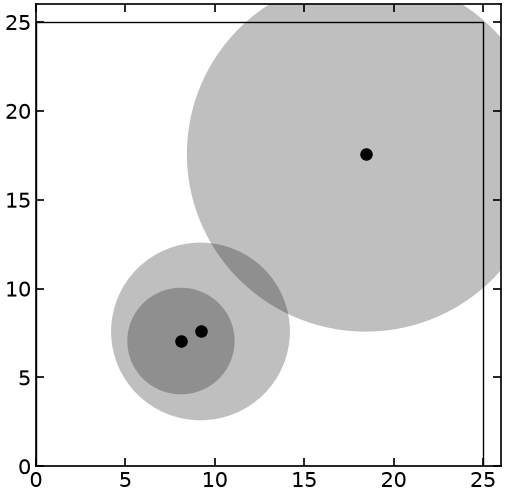

In [10]:
# Plot initial point


def plot_circles(m):
    """Plot circles using data in Pyomo model

    Arguments:
        m: Pyomo concrete model

    Returns:
        Nothing (but makes a figure)

    """

    # Create figure
    fig, ax = plt.subplots(1, figsize=(6, 6))

    # Adjust axes
    l = max(m.box_height.value, m.box_width.value) + 1
    ax.set_xlim(0, l)
    ax.set_ylim(0, l)

    # Draw box
    art = mpatches.Rectangle(
        (0, 0), width=m.box_width.value, height=m.box_height.value, fill=False
    )
    ax.add_patch(art)

    # Draw circles and mark center
    for i in m.CIRCLES:
        art2 = mpatches.Circle(
            (m.x[i].value, m.y[i].value),
            radius=pyo.value(m.R[i]),
            fill=True,
            alpha=0.25,
        )
        ax.add_patch(art2)

        plt.scatter(m.x[i].value, m.y[i].value, color="black")

    # Show plot
    plt.show()


plot_circles(model)

### Solve and Inspect the Solution

In [11]:
# Specify the solver
solver = pyo.SolverFactory("ipopt")

# Solve the model
results = solver.solve(model, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:       30
Number of nonzeros in Lagrangian Hessian.............:       12

Total number of variables............................:        8
                     variables with only lower bounds:        8
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number

   2  1.0446269e+02 2.46e+01 2.54e+00  -1.0 5.43e+00  -0.5 5.62e-01 3.57e-01h  1
   3  1.1075999e+02 0.00e+00 4.40e+00  -1.0 4.83e+00  -1.0 6.87e-01 1.00e+00h  1
   4  1.0931790e+02 0.00e+00 4.22e+00  -1.0 6.13e+01  -1.4 3.27e-01 2.76e-02f  3
   5  1.0505265e+02 0.00e+00 8.83e-01  -1.0 2.84e+00  -1.0 1.00e+00 9.20e-01f  1
   6  1.0163361e+02 0.00e+00 1.15e+00  -1.0 1.96e+00  -1.5 4.90e-01 9.10e-01h  1
   7  9.9775211e+01 0.00e+00 1.90e-01  -1.0 2.12e+00  -1.1 1.00e+00 8.60e-01f  1
   8  9.8947266e+01 0.00e+00 8.86e-01  -1.0 1.23e+02    -  3.86e-01 5.70e-02f  1


   9  9.8937271e+01 0.00e+00 2.06e-02  -1.0 7.04e-01  -1.5 1.00e+00 1.00e+00h  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  10  9.8325956e+01 0.00e+00 6.43e-03  -2.5 3.75e+00    -  9.93e-01 9.37e-01f  1
  11  9.8301250e+01 0.00e+00 2.66e-03  -2.5 4.81e+01    -  4.81e-01 1.00e+00h  1
  12  9.8301257e+01 0.00e+00 5.36e-04  -2.5 2.99e+01    -  1.00e+00 1.00e+00h  1
  13  9.8301256e+01 0.00e+00 2.96e-05  -2.5 2.59e+01    -  1.00e+00 1.00e+00h  1
  14  9.8301256e+01 0.00e+00 1.40e-06  -2.5 2.48e+00    -  1.00e+00 1.00e+00h  1
  15  9.8285159e+01 0.00e+00 2.69e-07  -3.8 3.80e-02    -  1.00e+00 1.00e+00h  1
  16  9.8284281e+01 0.00e+00 9.89e-10  -5.7 2.05e-03    -  1.00e+00 1.00e+00h  1
  17  9.8284270e+01 0.00e+00 9.89e-13  -8.6 1.62e-04    -  1.00e+00 1.00e+00h  1

Number of Iterations....: 17

                                   (scaled)                 (unscaled)
Objective...............:   9.8284270438747257e+01    9.8284270438747257e+01
Dual infeas

Next, we can inspect the solution. Because Pyomo is a Python extension, we can use Python (for loops, etc.) to programmatically inspect the solution.

Name	Value
box_height 	 19.999999803189603
box_width 	 29.14213541618403
x[A] 	 19.14213551493119
x[B] 	 4.999999951252128
x[C] 	 5.517274811159313
y[A] 	 9.999999901937443
y[B] 	 4.999999953543125
y[C] 	 15.729315741741795


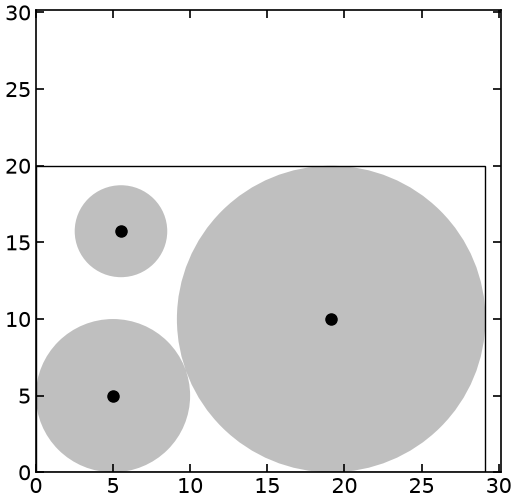

In [12]:
# Print variable values
print("Name\tValue")
for c in model.component_data_objects(pyo.Var):
    print(c.name, "\t", pyo.value(c))

# Plot solution
plot_circles(model)

In [13]:
# Print constraints
for c in model.component_data_objects(pyo.Constraint):
    print(
        c.name,
        "\t",
        pyo.value(c.lower),
        "\t",
        pyo.value(c.body),
        "\t",
        pyo.value(c.upper),
    )

left_x_con[A] 	 10.0 	 19.14213551493119 	 None
left_x_con[B] 	 5.0 	 4.999999951252128 	 None
left_x_con[C] 	 3.0 	 5.517274811159313 	 None
left_y_con[A] 	 10.0 	 9.999999901937443 	 None
left_y_con[B] 	 5.0 	 4.999999953543125 	 None
left_y_con[C] 	 3.0 	 15.729315741741795 	 None
right_x_con[A] 	 None 	 9.87471615587765e-08 	 0.0
right_x_con[B] 	 None 	 -19.1421354649319 	 0.0
right_x_con[C] 	 None 	 -20.624860605024715 	 0.0
right_y_con[A] 	 None 	 9.874784012708915e-08 	 0.0
right_y_con[B] 	 None 	 -9.999999849646478 	 0.0
right_y_con[C] 	 None 	 -1.2706840614478079 	 0.0
no_overlap_con[A,B] 	 225.0 	 224.99999778541928 	 None
no_overlap_con[A,C] 	 169.0 	 218.46188918942016 	 None
no_overlap_con[B,C] 	 64.0 	 115.38579056358121 	 None


### Reinitialize and Resolve

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
    <b>Activity</b>: Reinitialize the model, plot the initial point, resolve, and plot the solution. Is there more than one solution?
</div>

In [14]:
# Initialize and print the model

### BEGIN SOLUTION
initialize_circle_model(model)
model.pprint()
### END SOLUTION

1 Set Declarations
    CIRCLES : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    3 : {'A', 'B', 'C'}

1 Param Declarations
    R : Size=3, Index=CIRCLES, Domain=PositiveReals, Default=None, Mutable=True, Units=m
        Key : Value
          A :  10.0
          B :   5.0
          C :   3.0

4 Var Declarations
    box_height : Size=1, Index=None, Units=m
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :    25 :  None : False : False : PositiveReals
    box_width : Size=1, Index=None, Units=m
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :    25 :  None : False : False : PositiveReals
    x : Size=3, Index=CIRCLES, Units=m
        Key : Lower : Value              : Upper : Fixed : Stale : Domain
          A :     0 : 17.837985890347724 :  None : False : False : PositiveReals
          B :     0 :  9.765969541523559 :  None : False : False : Posi

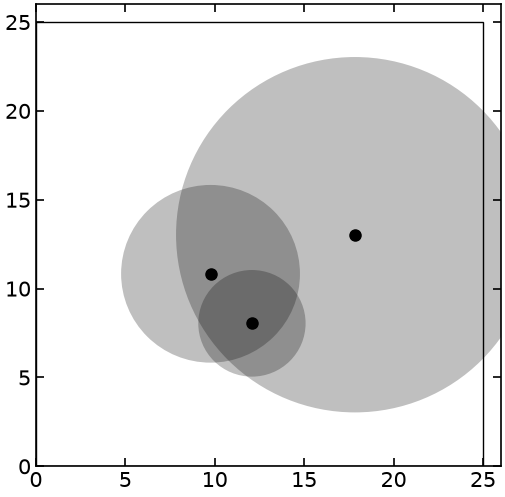

In [15]:
# Plot initial point
### BEGIN SOLUTION
plot_circles(model)
### END SOLUTION

In [16]:
# Solve the model
### BEGIN SOLUTION
results = solver.solve(model, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)
### END SOLUTION

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:       30
Number of nonzeros in Lagrangian Hessian.............:       12

Total number of variables............................:        8
                     variables with only lower bounds:        8
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number

   6  9.8917368e+01 0.00e+00 3.14e-03  -1.0 3.30e+01    -  1.00e+00 1.00e+00h  1
   7  9.8900000e+01 0.00e+00 1.04e-03  -1.0 7.91e+00    -  1.00e+00 1.00e+00h  1
   8  9.8394513e+01 0.00e+00 4.20e-04  -1.7 1.76e+00    -  1.00e+00 1.00e+00h  1


   9  9.8284893e+01 0.00e+00 4.60e-05  -3.8 2.95e-01    -  1.00e+00 9.98e-01h  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  10  9.8284281e+01 0.00e+00 5.07e-08  -5.7 5.23e-02    -  1.00e+00 1.00e+00h  1
  11  9.8284270e+01 0.00e+00 3.77e-11  -8.6 4.78e-03    -  1.00e+00 1.00e+00h  1

Number of Iterations....: 11

                                   (scaled)                 (unscaled)
Objective...............:   9.8284270438748450e+01    9.8284270438748450e+01
Dual infeasibility......:   3.7706208248038017e-11    3.7706208248038017e-11
Constraint violation....:   0.0000000000000000e+00    0.0000000000000000e+00
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.7106270175642552e-09    2.7106270175642552e-09
Overall NLP error.......:   2.7106270175642552e-09    2.7106270175642552e-09


Number of objective function evaluations             = 12
Number of objective gradient evaluations            

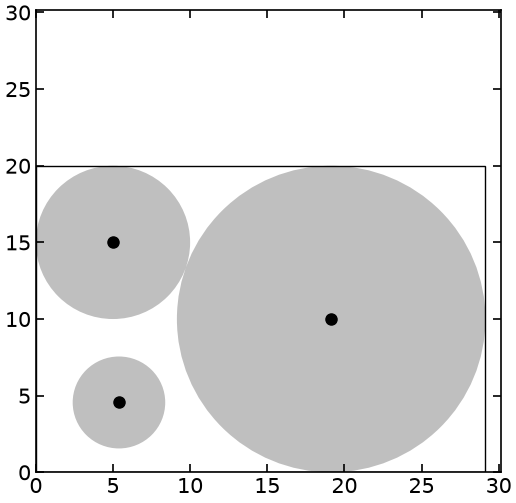

In [17]:
# Plot solution
### BEGIN SOLUTION
plot_circles(model)
### END SOLUTION

## The Two Local Solutions, Side by Side

The activity above landed on two different boxes from two different starting
arrangements. Let's do that **deliberately**, on the instance the lecture
handout uses --- $R = (1.0,\ 0.7,\ 0.6)$, "three circles of different sizes" as
Biegler's Example 4.4 puts it --- and build the figure that appears in the
handout.

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;">
<b>Pattern to learn: solve, then extract, then plot.</b> Do not solve and plot in
the same breath. Solve the model, then <b>extract</b> the answer into plain
Python, then <b>plot the extracted results</b>. Three cells, three jobs.

<ul>
<li><b>You can debug the plot without re-solving.</b> Getting three hatched circles,
two dimension arrows and a pair of titles to sit where you want them takes a dozen
attempts. Each one should cost milliseconds, not a fresh call to Ipopt.</li>
<li><b>You can archive the answer.</b> Store the extracted numbers next to your paper
and you can redraw the figure a year later, on a machine with no solver installed,
from the numbers you actually reported.</li>
<li><b>The plot cell cannot lie about the model.</b> If it only ever sees the
extracted results, it cannot quietly recompute something different from what you
solved.</li>
</ul>

In research code, <code>pickle</code> is the quick way to store the extracted
results, and that is what we recommend there. Here the archive is
<b>committed to this repository</b>, so it is written as JSON instead: a pickle in
version control is an unreviewable binary that stops loading the next time a
library is upgraded, and nobody can read its diff.
</div>

In [18]:
# ---------- SOLVE ----------------------------------------------------------
# Nothing is plotted in this cell. This is the only cell below that needs a
# solver.
#
# THE INSTANCE. Biegler prints no numerical radii -- his Figure 4.4 is a sketch
# -- so R = (1.0, 0.7, 0.6) is ours. It was chosen because it has *two*
# certified local minima that are 13.6% apart in perimeter: far enough that the
# two boxes differ visibly on the page, and the radii are visibly unequal, as
# "three circles of different sizes" requires. Other triples give only one, and
# then the picture below is impossible to draw.
lecture_radii = {"1": 1.0, "2": 0.7, "3": 0.6}

# The loose box every run starts from. Biegler's second bullet on p. 68 is
# "change the initial arrangement of the circles and manually shrink the walls
# of the box", so the starting walls are part of the story and get drawn.
BOX_INIT = 4.6

# Two starting arrangements, both feasible, both describable in words.
starts = {
    "strung along the diagonal": {"1": (1.0, 1.0), "2": (2.4, 2.3), "3": (3.4, 3.4)},
    "one circle per corner": {"1": (1.2, 1.2), "2": (3.8, 0.7), "3": (0.7, 3.9)},
}

# ⚠ R_2 SITS SLIGHTLY OFF THE DIAGONAL ON PURPOSE, and that is a lesson rather
# than bookkeeping. This model is symmetric under swapping the two axes
# (A <-> B and x <-> y together). A start with all three centers exactly on the
# line y = x is a fixed point of that symmetry, and Ipopt walks straight down
# it to the symmetric stationary point: a *square* box, perimeter 14.885, which
# is not a local minimum at all. Measured with Pyomo 6.10.1 + Ipopt: centers
# (1.0, 1.0), (2.3, 2.3), (3.4, 3.4) in a box of 4.6 return 14.885, and the
# same start with the box written as 4.599999999999997 returns 11.488. The
# tie-break is being decided by the last bits of the mantissa. Break the
# symmetry yourself; do not leave it to round-off.


def solve_circle_packing(radii, centers, box_init=BOX_INIT):
    """Build, initialize from a named arrangement, and solve. Returns the model."""
    m = create_circle_model(radii)
    m.box_height = box_init
    m.box_width = box_init
    for i, (x0, y0) in centers.items():
        m.x[i] = x0
        m.y[i] = y0
    status = pyo.SolverFactory("ipopt").solve(m)
    assert pyo.check_optimal_termination(status), (
        f"solve failed: {status.solver.termination_condition}"
    )
    return m


def extract_point(m):
    """Pyomo model -> plain Python. After this, nothing needs the model again."""
    return {
        "A": pyo.value(m.box_height),
        "B": pyo.value(m.box_width),
        "perimeter": pyo.value(m.obj),
        "centers": {i: (pyo.value(m.x[i]), pyo.value(m.y[i])) for i in m.CIRCLES},
    }


points = {
    name: extract_point(solve_circle_packing(lecture_radii, centers))
    for name, centers in starts.items()
}

for name, p in points.items():
    print(
        f"start {name:28s} -> A = {p['A']:.4f} m, B = {p['B']:.4f} m, "
        f"perimeter = {p['perimeter']:.4f} m"
    )

names = list(starts)
penalty = 100.0 * (points[names[1]]["perimeter"] / points[names[0]]["perimeter"] - 1.0)
print(f"the two answers differ by {penalty:.1f}% of the better one")

start strung along the diagonal    -> A = 2.5961 m, B = 3.1478 m, perimeter = 11.4880 m
start one circle per corner        -> A = 3.1492 m, B = 3.3733 m, perimeter = 13.0450 m
the two answers differ by 13.6% of the better one


In [19]:
# ---------- ARE THEY REALLY LOCAL MINIMA? ----------------------------------
# The caption of the handout figure claims both answers are genuine local
# solutions. That is a claim, so it gets checked.
#
# ⚠ THE OBVIOUS CHECK IS THE WRONG ONE. Perturb the answer, re-solve, see
# whether it comes back: that measures the *basin radius*, not local
# minimality. A genuine local minimum is escaped by any perturbation larger
# than its basin, so run that test with a large perturbation and you will
# conclude, falsely, that this problem has one local solution.
#
# The test used instead is a TRUST-REGION CERTIFICATE. Minimize the objective
# over the feasible set intersected with a ball ||z - z*|| <= delta, from many
# starts inside that ball. If nothing in the ball beats z*, then z* is a local
# minimum out to radius delta. delta = 0.5 is large next to a box of side ~3.
#
# This matters: Ipopt also stops at points that are NOT local minima -- the
# symmetric square box at 14.885 noted above is one, and the certificate
# improves on it immediately.

DELTA = 0.5
N_TRY = 40


def best_in_ball(radii, z_star, delta=DELTA, n_try=N_TRY, seed=17):
    """Smallest perimeter attainable inside ||z - z*|| <= delta and feasible.

    Returns the perimeter at z* itself if nothing in the ball improves on it.
    A smaller value means z* is a point the solver stopped at and nothing more.
    """
    rng = random.Random(seed)  # seeded: an unseeded certificate is not evidence
    circles = list(radii)
    n = 2 + 2 * len(circles)
    m_units = pyo.units.m
    best = z_star["perimeter"]
    opt = pyo.SolverFactory("ipopt")

    for _ in range(n_try):
        # A point uniform in the ball: random direction, radius ~ U(0,1)^(1/n).
        d = [rng.gauss(0.0, 1.0) for _ in range(n)]
        scale = delta * rng.random() ** (1.0 / n) / sum(v * v for v in d) ** 0.5
        d = [v * scale for v in d]

        m = create_circle_model(radii)
        m.box_height = z_star["A"] + d[0]
        m.box_width = z_star["B"] + d[1]
        for k, i in enumerate(circles):
            m.x[i] = z_star["centers"][i][0] + d[2 + 2 * k]
            m.y[i] = z_star["centers"][i][1] + d[3 + 2 * k]

        # The ball itself, as one extra constraint on the same model.
        m.trust_region = pyo.Constraint(
            expr=(m.box_height - z_star["A"] * m_units) ** 2
            + (m.box_width - z_star["B"] * m_units) ** 2
            + sum(
                (m.x[i] - z_star["centers"][i][0] * m_units) ** 2
                + (m.y[i] - z_star["centers"][i][1] * m_units) ** 2
                for i in circles
            )
            <= delta**2 * m_units**2
        )

        status = opt.solve(m)
        if pyo.check_optimal_termination(status):
            best = min(best, pyo.value(m.obj))
    return best


certificate = {}
for name, p in points.items():
    certificate[name] = best_in_ball(lecture_radii, p)
    verdict = "LOCAL MINIMUM" if certificate[name] > p["perimeter"] - 1e-3 else "NOT a minimum"
    print(
        f"{name:28s} perimeter {p['perimeter']:.5f}, best in ball of radius "
        f"{DELTA} = {certificate[name]:.5f}  ->  {verdict}"
    )

strung along the diagonal    perimeter 11.48797, best in ball of radius 0.5 = 11.48797  ->  LOCAL MINIMUM


one circle per corner        perimeter 13.04503, best in ball of radius 0.5 = 13.04503  ->  LOCAL MINIMUM


In [20]:
# ---------- ARCHIVE --------------------------------------------------------
# figures/results/packing-local-solutions.json, committed to the repository.
# `source_tag` points at the model cell above, so scripts/check_results_fresh.py
# can tell you when the model has changed and these numbers have not.
# A no-op on Colab, where there is nothing to commit to.

results = {
    "radii": dict(lecture_radii),
    "box_init": BOX_INIT,
    "delta": DELTA,
    "panels": [
        {
            "name": name,
            "start": {i: list(starts[name][i]) for i in starts[name]},
            "A": points[name]["A"],
            "B": points[name]["B"],
            "perimeter": points[name]["perimeter"],
            "centers": {i: list(points[name]["centers"][i]) for i in lecture_radii},
            "best_in_ball": certificate[name],
        }
        for name in starts
    ],
}

helper.save_results(
    "packing-local-solutions",
    results,
    notebook="notebooks/1-dev/NLP.ipynb",
    source_tag="handout:circle-packing-model",
    description="Biegler Example 4.4 with R = (1.0, 0.7, 0.6), solved twice "
    "from two starting arrangements: two local solutions 13.6% apart in "
    "perimeter, each certified by a trust-region check of radius 0.5.",
    solver="Ipopt via Pyomo",
)

[pyomo_results] wrote figures/results/packing-local-solutions.json


'/Users/adowling/DowlingLab/Teaching/optimization/figures/results/packing-local-solutions.json'

[pyomo_results] wrote media/figures/packing-local-solutions.png and .pdf


'/Users/adowling/DowlingLab/Teaching/optimization/media/figures/packing-local-solutions.png'

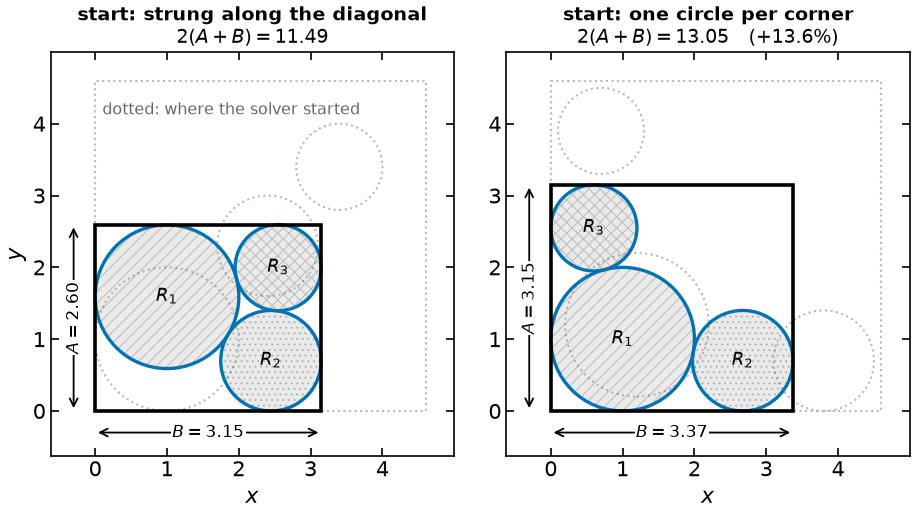

In [21]:
# The PLOTTING function: it takes the extracted results, not the Pyomo model.
#
# Everything it needs is in `results`, and nothing else -- no model, no solver.
# That is what lets you re-run this one cell as many times as it takes to get
# the labels where you want them.
#
# This cell is tagged `figure:packing-local-solutions`, which makes it the
# single source of the figure the lecture handout prints. See figures/README.md;
# figures/render_from_notebook.py re-runs exactly this cell against the archived
# JSON when the house style changes. That driver binds `helper` for the cell,
# so this cell may use it without importing anything.

from matplotlib.patches import Circle, Rectangle


def plot_packing_local_solutions(results):
    """Two local solutions of the circle-packing NLP, from two starting guesses.

    WHY THIS FIGURE EXISTS. The model above is nonconvex -- the No Overlap
    constraints are -- so the convexity theorem does not apply and

        "the optimum you find depends on where you start."

    This is the evidence for that sentence, and it is Biegler's own second
    bullet on p. 68. Same model, same solver, same tolerances, two starting
    arrangements, two different answers.

    Both are local solutions: neither is refuted by anything local, which is
    the entire content of "no guarantee of a global solution". The certificate
    that says so is computed in the solve cells above and archived alongside
    the coordinates.

    GREYSCALE. The three circles carry three genuinely different hatch families
    -- lines, dots, crosses -- and their own labels, so they are told apart
    without colour. The starting arrangement is dotted and unfilled against the
    solid, filled solution: a linestyle contrast, not a colour one. The box is
    black in both panels.
    """
    radii = results["radii"]
    panels = results["panels"]
    box0 = results["box_init"]
    circles = list(radii)

    # Hatch literals copied from figures/plots/_house.py, which is NOT on disk
    # on Colab and must not be imported here:
    #   HATCH_CYCLE = ("///", "\\\\\\", "...", "xxx", "|||", "---")
    #   SHADE_ALPHA = 0.18
    # ⚠ HATCH_CYCLE[1], "\\\", is skipped deliberately. Three circles need
    # three textures, and these three spend three different texture FAMILIES,
    # so every pair differs in kind. Restoring [1] puts two of the three in the
    # same family, separated only by the SIGN of the slope -- the most fragile
    # cue here, because the hatch is drawn pale at low alpha inside circles
    # that touch.
    hatches = ("///", "...", "xxx")
    shade_alpha = 0.18
    hatch_colour = plt.rcParams["hatch.color"]
    blue = "#0072B2"  # Okabe-Ito; the solved circles are the only colour here
    lim_lo, lim_hi = -0.62, 5.00

    def draw_circles(ax, centers, solution):
        """One arrangement. `solution` toggles solved vs starting guess."""
        for k, i in enumerate(circles):
            x, y = centers[i]
            if solution:
                ax.add_patch(Circle((x, y), radii[i], facecolor="0.55",
                                    alpha=shade_alpha, hatch=hatches[k],
                                    edgecolor=hatch_colour, linewidth=0.0,
                                    zorder=2))
                ax.add_patch(Circle((x, y), radii[i], facecolor="none",
                                    edgecolor=blue, linewidth=2.4, zorder=3))
                ax.annotate("$R_%d$" % (k + 1), xy=(x, y), fontsize=13,
                            ha="center", va="center", zorder=6)
            else:
                ax.add_patch(Circle((x, y), radii[i], facecolor="none",
                                    edgecolor="0.72", linestyle=":",
                                    linewidth=1.5, zorder=1))

    def draw_box(ax, A, B):
        """The enclosing box, with its two dimensions written on it."""
        ax.add_patch(Rectangle((0.0, 0.0), B, A, facecolor="none",
                               edgecolor="black", linewidth=2.6, zorder=4))
        ax.annotate("", xy=(-0.30, 0.0), xytext=(-0.30, A),
                    arrowprops=dict(arrowstyle="<->", color="black", lw=1.3))
        ax.annotate("$A = %.2f$" % A, xy=(-0.30, 0.5 * A), fontsize=12.5,
                    ha="center", va="center", rotation=90,
                    bbox=dict(facecolor="white", edgecolor="none", pad=1.0))
        ax.annotate("", xy=(0.0, -0.30), xytext=(B, -0.30),
                    arrowprops=dict(arrowstyle="<->", color="black", lw=1.3))
        ax.annotate("$B = %.2f$" % B, xy=(0.5 * B, -0.30), fontsize=12.5,
                    ha="center", va="center",
                    bbox=dict(facecolor="white", edgecolor="none", pad=1.0))

    def frame(ax, title):
        ax.set_xlim(lim_lo, lim_hi)
        ax.set_ylim(lim_lo, lim_hi)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("$x$")
        ax.set_title(title, fontsize=13.5)
        ax.set_xticks([0, 1, 2, 3, 4])
        ax.set_yticks([0, 1, 2, 3, 4])

    # ⚠ figsize is set HERE. helper.set_plotting_style() overrides the house
    # default for on-screen readability and render_from_notebook.py does not,
    # so a figure that relied on the default would come out at two different
    # aspect ratios depending on who generated it.
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 5.0))
    axes[0].set_ylabel("$y$")

    penalty = 100.0 * (panels[1]["perimeter"] / panels[0]["perimeter"] - 1.0)
    # ⚠ f-strings, not %-formatting, for these two: scripts/check_greyscale.py
    # blanks any line whose first non-blank character is `%` (it reads it as a
    # Jupyter line magic), so a `% (...)` continuation line makes the whole
    # notebook score "unparseable".
    titles = [
        f"start: {panels[0]['name']}\n$2(A+B) = {panels[0]['perimeter']:.2f}$",
        f"start: {panels[1]['name']}\n$2(A+B) = {panels[1]['perimeter']:.2f}$"
        f"   $(+{penalty:.1f}\\%)$",
    ]

    for ax, panel, title in zip(axes, panels, titles):
        frame(ax, title)
        # The loose box every run starts from: p. 68 is about shrinking these
        # walls, so the walls have to be on the page.
        ax.add_patch(Rectangle((0.0, 0.0), box0, box0, facecolor="none",
                               edgecolor="0.72", linestyle=":", linewidth=1.5,
                               zorder=1))
        draw_circles(ax, panel["start"], solution=False)
        draw_circles(ax, panel["centers"], solution=True)
        draw_box(ax, panel["A"], panel["B"])

    axes[0].annotate("dotted: where the solver started", xy=(0.10, 4.30),
                     fontsize=11.5, ha="left", va="top", color="0.40")

    fig.tight_layout()
    return fig


fig = plot_packing_local_solutions(results)

# Write media/figures/packing-local-solutions.{png,pdf} -- what the lecture
# handout \includegraphics. A no-op on Colab, where there is no repo to write to.
helper.save_figure(fig, "packing-local-solutions")

## Multistart

The activity above shows that two starting points can give two different boxes.
That raises the obvious question: *how many* different boxes are there, and how
often does the solver find the best one?

A **multistart** answers that empirically. Solve the same model from many random
initial points, collect the objective values, and look at the distribution. Note
what this does and does not buy you: it raises confidence that you have found the
global solution, but it is **never a certificate**. Proving global optimality of a
nonconvex program requires a global solver, which is a topic for later in the
course.

Two practical points before the code:

1. **Seed the random number generator.** A histogram built from an unseeded
   sampler is a different figure every time the notebook runs, and a number you
   cannot reproduce is a number you cannot defend.
2. **Sample widely enough to matter.** The default `spread=10` used above draws
   the centers from a window smaller than the box itself, and essentially every
   start then lands in the same basin. We widen it below.


In [22]:
def multistart_circle_packing(
    circle_data, n_starts=50, seed=0, spread=40, box_init=40, tee=False
):
    """Solve the circle packing model from many random initial points

    Arguments:
        circle_data: dictionary with keys=circle name and value=radius (float)
        n_starts: number of random initializations (int)
        seed: seed for the random number generator, so the result reproduces
        spread: width of the uniform window the centers are drawn from
        box_init: initial value for both box dimensions
        tee: print solver output

    Returns:
        results: pandas DataFrame, one row per start, with the objective and
            the box dimensions (NaN if that start did not solve)
    """
    # Reproducibility. Reseeding here means this cell gives the same answer no
    # matter which other cells were run first.
    random.seed(seed)

    solver = pyo.SolverFactory("ipopt")

    rows = []
    for k in range(n_starts):
        m = create_circle_model(circle_data)
        initialize_circle_model(
            m, height_init=box_init, width_init=box_init, spread=spread
        )
        res = solver.solve(m, tee=tee)
        if pyo.check_optimal_termination(res):
            rows.append(
                {
                    "start": k,
                    "perimeter": pyo.value(m.obj),
                    "A": pyo.value(m.box_height),
                    "B": pyo.value(m.box_width),
                }
            )
        else:
            rows.append(
                {"start": k, "perimeter": float("nan"), "A": float("nan"),
                 "B": float("nan")}
            )

    return pd.DataFrame(rows)


ms = multistart_circle_packing(circle_data, n_starts=50, seed=0)

n_failed = int(ms["perimeter"].isna().sum())
print(f"{len(ms)} starts, {n_failed} failed to converge")
print(f"Best perimeter found: {ms['perimeter'].min():.4f}")


50 starts, 0 failed to converge
Best perimeter found: 98.2843


In [23]:
# How many distinct local solutions did we land on?
counts = (
    ms["perimeter"]
    .round(3)
    .value_counts()
    .rename_axis("perimeter")
    .reset_index(name="number of starts")
    .sort_values("perimeter")
    .reset_index(drop=True)
)
counts["fraction"] = counts["number of starts"] / len(ms)
display(counts)


,perimeter,number of starts,fraction
0,98.284,42,0.84
1,101.977,3,0.06
2,106.193,5,0.10


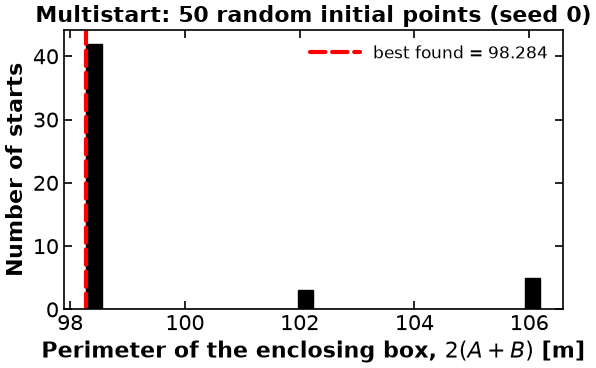

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(ms["perimeter"].dropna(), bins=30, edgecolor="black")
ax.axvline(
    ms["perimeter"].min(),
    color="red",
    linestyle="--",
    label=f"best found = {ms['perimeter'].min():.3f}",
)
ax.set_xlabel("Perimeter of the enclosing box, $2(A + B)$ [m]")
ax.set_ylabel("Number of starts")
ax.set_title(f"Multistart: {len(ms)} random initial points (seed 0)")
ax.legend()
plt.tight_layout()
plt.show()


In [25]:
# Which start gave the best box?
best_start = int(ms["perimeter"].idxmin())
print(f"Best start: #{best_start}")
print(f"  perimeter = {ms.loc[best_start, 'perimeter']:.4f} m")
print(f"  A = {ms.loc[best_start, 'A']:.4f} m, B = {ms.loc[best_start, 'B']:.4f} m")


Best start: #41
  perimeter = 98.2843 m
  A = 20.0000 m, B = 29.1421 m


The histogram has a few sharp spikes, not a smooth spread: Ipopt is converging to a
small number of distinct local solutions, and the spikes are those solutions. Most
starts find the best one, but a meaningful minority do not.

Three things to take from this:

* **The best value found is far more reproducible than the fraction that finds it.**
  The best perimeter is the same for every seed we tried; the count is not. If you
  report a fraction, report the sampler and the seed with it, because the fraction
  depends on both.
* **A multistart is evidence, not proof.** Fifty starts all agreeing is good
  evidence that the best value found is global. It is not a certificate, and no
  number of starts makes it one.
* **The sampler is part of the experiment.** Drawing the centers from a narrow
  window makes every start look identical and the problem look convex. It is not.


<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;">
<b>Activity</b>: Change the seed and re-run the multistart. Does the best perimeter
change? Does the <i>fraction</i> of starts that find it change? Which of those two
would you be willing to put in a report?
</div>


## Take Away Messages
* Nonlinear programs may be nonconvex. For nonconvex problems, there often exist many local optima that are not also global optima.
* We will learn how to mathematically define convexity and analyze this property.
* Initialization is really important in optimization problems with nonlinear objectives or constraints!
* There are specialized solvers for linear programs, quadratic programs, and convex programs. In this class, we will focus on more general algorithms for (non)convex nonlinear programs including the algorithms used by the `ipopt` solver.